In [1]:
# ==========================================
# 1. IMPORTATIONS ET CONFIGURATION
# ==========================================
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import models, transforms
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt
import cv2
import requests
from io import BytesIO

In [2]:
# Configuration du device (GPU si dispo)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Exécution sur : {device}")


Exécution sur : cuda


In [3]:
# ==========================================
# 2. CLASSE GradCAM (Le Cœur de l'XAI)
# ==========================================
class GradCAM:
    def __init__(self, model, target_layer):
        """
        model : Le modèle CNN (ex: ResNet50)
        target_layer : La dernière couche convolutionnelle où on veut regarder
        """
        self.model = model.eval() # Mode évaluation important
        self.target_layer = target_layer
        self.gradients = None
        self.activations = None
        
        # Enregistrement des "Hooks" pour intercepter les données
        # 1. Hook pour les activations (Forward pass)
        self.target_layer.register_forward_hook(self.save_activation)
        # 2. Hook pour les gradients (Backward pass)
        self.target_layer.register_full_backward_hook(self.save_gradient)

    def save_activation(self, module, input, output):
        self.activations = output

    def save_gradient(self, module, grad_input, grad_output):
        # grad_output est un tuple, on prend le premier élément
        self.gradients = grad_output[0]

    def forward(self, input_image, class_idx=None):
        """
        input_image : Tensor (1, C, H, W)
        class_idx : L'index de la classe à expliquer (si None, prend la prédite)
        """
        # A. Passage Avant (Forward)
        output = self.model(input_image)
        
        if class_idx is None:
            class_idx = torch.argmax(output, dim=1).item()
            
        # B. Mise à zéro des gradients précédents
        self.model.zero_grad()
        
        # C. Rétropropagation (Backward) ciblée
        # On veut expliquer le score de la classe cible
        score = output[0, class_idx]
        score.backward() # Cela déclenche le hook save_gradient
        
        # D. Calcul de la Heatmap (La mathématique de Grad-CAM)
        # 1. Global Average Pooling sur les gradients (Poids alpha)
        gradients = self.gradients.cpu().data.numpy()[0] # (K, H, W)
        activations = self.activations.cpu().data.numpy()[0] # (K, H, W)
        
        weights = np.mean(gradients, axis=(1, 2)) # Moyenne spatiale -> vecteur de poids (K,)
        
        # 2. Combinaison linéaire des activations pondérées par les poids
        cam = np.zeros(activations.shape[1:], dtype=np.float32)
        for i, w in enumerate(weights):
            cam += w * activations[i]
            
        # 3. Fonction ReLU (On ne garde que l'influence positive)
        cam = np.maximum(cam, 0)
        
        # 4. Normalisation pour l'affichage (entre 0 et 1)
        if np.max(cam) != 0:
            cam = cam / np.max(cam)
        else:
            cam = cam # Évite la division par zéro
            
        return cam, class_idx, score.item()


In [4]:
# ==========================================
# 3. FONCTIONS UTILITAIRES (Affichage)
# ==========================================
def preprocess_image(img_path):
    """Charge et normalise l'image comme ImageNet"""
    preprocess = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], 
                             std=[0.229, 0.224, 0.225]),
    ])
    
    # Gestion chargement URL ou Local
    if img_path.startswith('http'):
        response = requests.get(img_path)
        img = Image.open(BytesIO(response.content)).convert('RGB')
    else:
        img = Image.open(img_path).convert('RGB')
        
    input_tensor = preprocess(img).unsqueeze(0).to(device) # Ajout dimension batch
    return img, input_tensor

def show_results(original_img, heatmap, predicted_class, confidence):
    """Superpose la heatmap sur l'image originale"""
    # Redimensionner la heatmap à la taille de l'image originale
    original_img = np.array(original_img.resize((224, 224)))
    heatmap_resized = cv2.resize(heatmap, (224, 224))
    
    # Convertir en fausses couleurs (JET colormap)
    heatmap_colored = np.uint8(255 * heatmap_resized)
    heatmap_colored = cv2.applyColorMap(heatmap_colored, cv2.COLORMAP_JET)
    
    # Superposition (Weighted add)
    superimposed_img = heatmap_colored * 0.4 + original_img * 0.6
    superimposed_img = np.uint8(superimposed_img) # Conversion finale
    
    # Affichage Matplotlib
    fig, ax = plt.subplots(1, 3, figsize=(15, 5))
    
    ax[0].imshow(original_img)
    ax[0].set_title("Image Originale")
    ax[0].axis('off')
    
    ax[1].imshow(heatmap_resized, cmap='jet')
    ax[1].set_title("Grad-CAM Heatmap (Brute)")
    ax[1].axis('off')
    
    ax[2].imshow(superimposed_img)
    ax[2].set_title(f"Overlay\nPred: {predicted_class} ({confidence:.2f})")
    ax[2].axis('off')
    
    plt.tight_layout()
    plt.show()


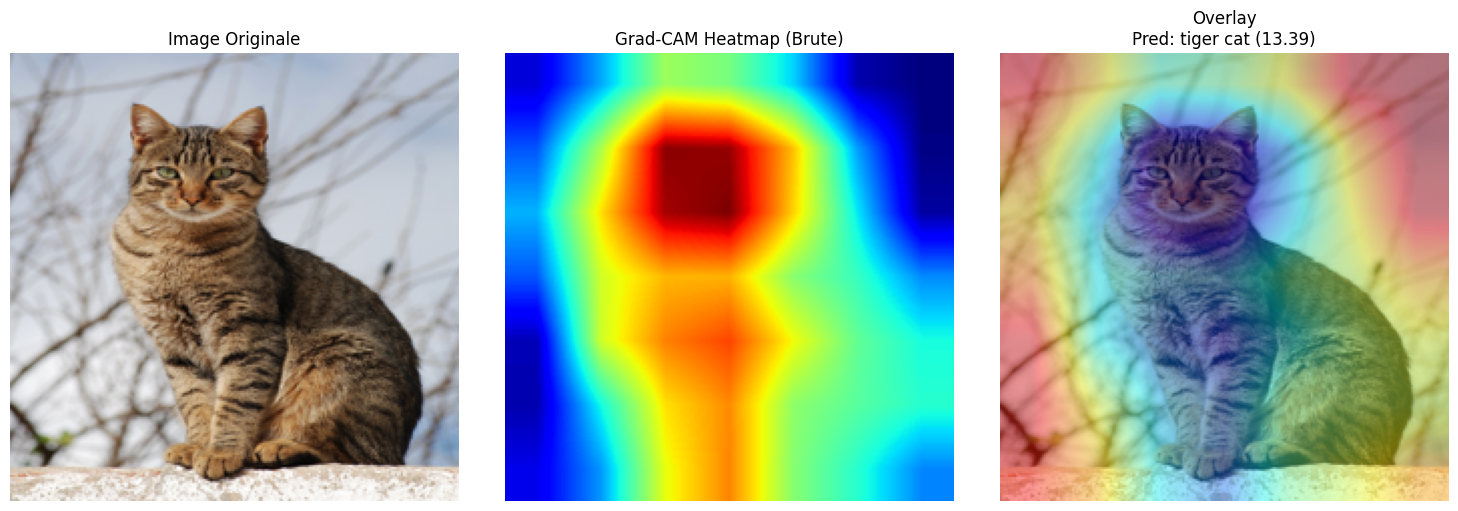

In [6]:
# ==========================================
# 4. EXÉCUTION PRINCIPALE
# ==========================================
if __name__ == "__main__":
    # 1. Charger un modèle pré-entraîné (ResNet50 est standard pour ça)
    model = models.resnet50(pretrained=True).to(device)
    
    # 2. Identifier la "Target Layer"
    # Pour ResNet50, c'est la dernière couche du dernier bloc "bottleneck" (layer4)
    target_layer = model.layer4[-1] 
    
    # 3. Initialiser notre XAI
    grad_cam = GradCAM(model, target_layer)
    
    # 4. Charger une image (Chien/Chat pour l'exemple)
    # Remplacer par le chemin de votre fichier local 'data/cat.jpg' si besoin
    img_url = "/kaggle/input/cat-november-2010-1a-jpg/Cat_November_2010-1a.jpg"
    original_img, input_tensor = preprocess_image(img_url)
    
    # 5. Lancer l'explication
    heatmap, pred_idx, confidence = grad_cam.forward(input_tensor)
    
    # Récupérer le nom de la classe (ImageNet classes)
    # (Juste pour l'affichage propre)
    labels_url = "https://raw.githubusercontent.com/pytorch/hub/master/imagenet_classes.txt"
    labels = requests.get(labels_url).text.split('\n')
    class_name = labels[pred_idx]
    
    # 6. Visualiser
    show_results(original_img, heatmap, class_name, confidence)

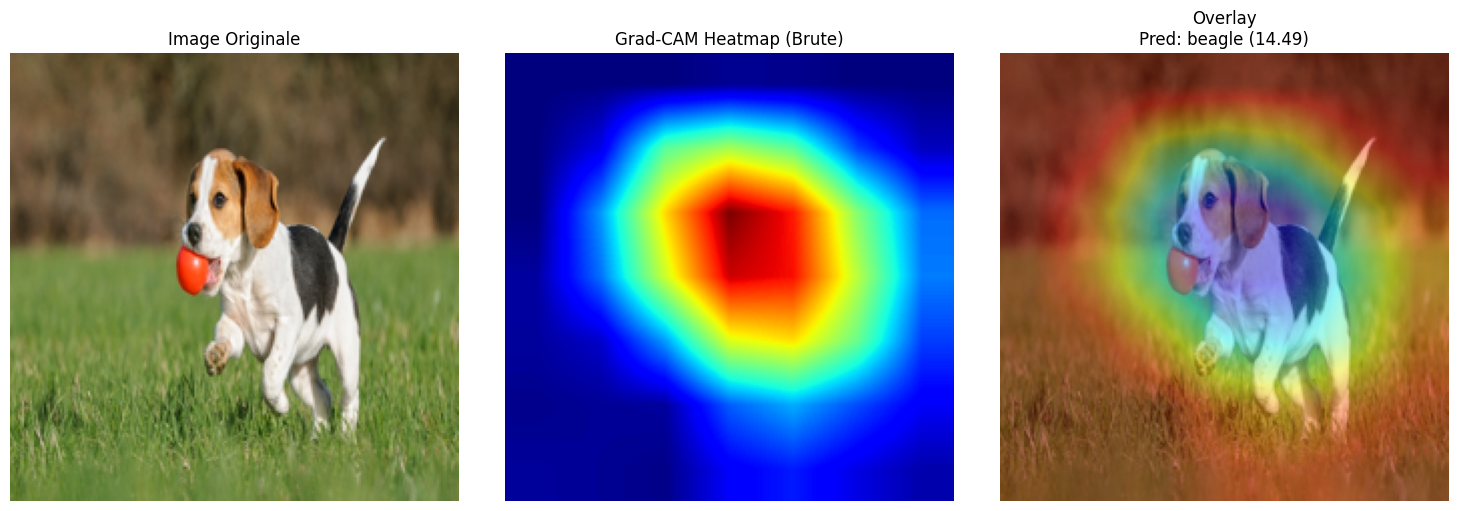

In [7]:
# ==========================================
# 4. EXÉCUTION PRINCIPALE
# ==========================================
if __name__ == "__main__":
    # 1. Charger un modèle pré-entraîné (ResNet50 est standard pour ça)
    model = models.resnet50(pretrained=True).to(device)
    
    # 2. Identifier la "Target Layer"
    # Pour ResNet50, c'est la dernière couche du dernier bloc "bottleneck" (layer4)
    target_layer = model.layer4[-1] 
    
    # 3. Initialiser notre XAI
    grad_cam = GradCAM(model, target_layer)
    
    # 4. Charger une image (Chien/Chat pour l'exemple)
    # Remplacer par le chemin de votre fichier local 'data/cat.jpg' si besoin
    img_url = "/kaggle/input/dog-img/ed7a-how-to-buy-a-puppy-article-dog.png"
    original_img, input_tensor = preprocess_image(img_url)
    
    # 5. Lancer l'explication
    heatmap, pred_idx, confidence = grad_cam.forward(input_tensor)
    
    # Récupérer le nom de la classe (ImageNet classes)
    # (Juste pour l'affichage propre)
    labels_url = "https://raw.githubusercontent.com/pytorch/hub/master/imagenet_classes.txt"
    labels = requests.get(labels_url).text.split('\n')
    class_name = labels[pred_idx]
    
    # 6. Visualiser
    show_results(original_img, heatmap, class_name, confidence)

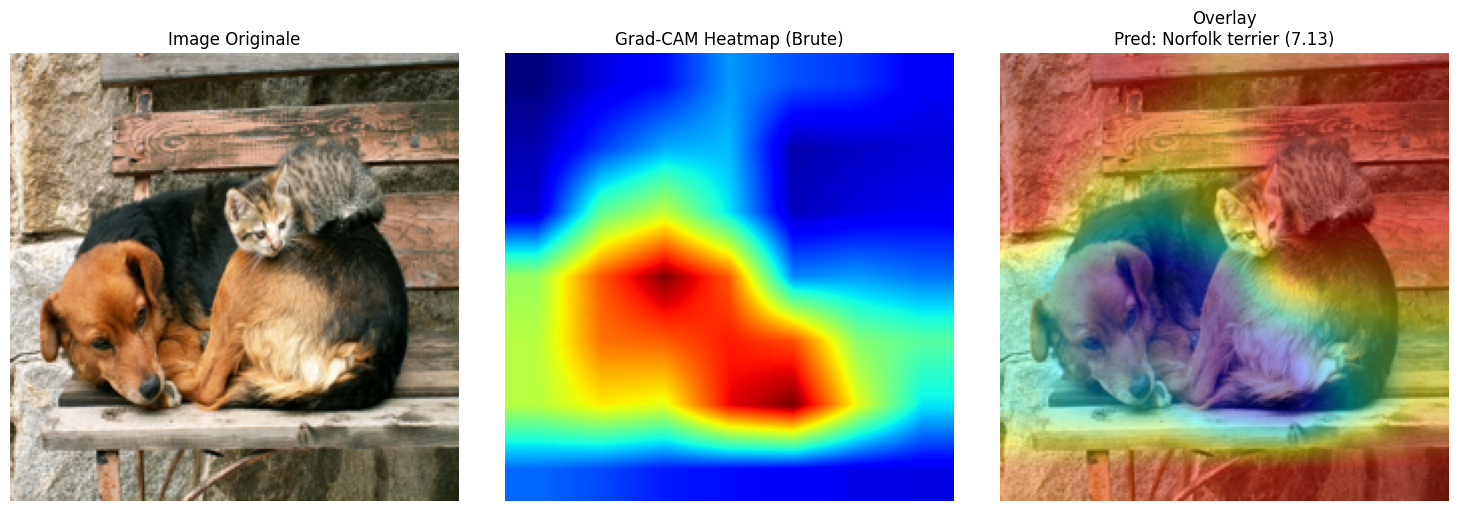

In [8]:
# ==========================================
# 4. EXÉCUTION PRINCIPALE
# ==========================================
if __name__ == "__main__":
    # 1. Charger un modèle pré-entraîné (ResNet50 est standard pour ça)
    model = models.resnet50(pretrained=True).to(device)
    
    # 2. Identifier la "Target Layer"
    # Pour ResNet50, c'est la dernière couche du dernier bloc "bottleneck" (layer4)
    target_layer = model.layer4[-1] 
    
    # 3. Initialiser notre XAI
    grad_cam = GradCAM(model, target_layer)
    
    # 4. Charger une image (Chien/Chat pour l'exemple)
    # Remplacer par le chemin de votre fichier local 'data/cat.jpg' si besoin
    img_url = "/kaggle/input/dog-and-cat/dog-and-cat-get-along.jpg"
    original_img, input_tensor = preprocess_image(img_url)
    
    # 5. Lancer l'explication
    heatmap, pred_idx, confidence = grad_cam.forward(input_tensor)
    
    # Récupérer le nom de la classe (ImageNet classes)
    # (Juste pour l'affichage propre)
    labels_url = "https://raw.githubusercontent.com/pytorch/hub/master/imagenet_classes.txt"
    labels = requests.get(labels_url).text.split('\n')
    class_name = labels[pred_idx]
    
    # 6. Visualiser
    show_results(original_img, heatmap, class_name, confidence)